### [Simulate Stock Prices with Python](https://medium.com/coding-nexus/05d1cfdce337)

> Stock price simulation is a building block of quantitative finance. It’s how we model uncertainty, estimate risk, and price derivatives like options. One of the most common ways to simulate stock prices is by using **Geometric Brownian Motion (GBM)**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.style.use('ggplot')

In [2]:
s0 = 131.00       # starting stock price
sigma = 0.25      # annual volatility (25%)
mu = 0.35         # annual return (35%)
paths = 1000      # number of simulated price paths
dt = 1.0 / 252.0  # time step (1 trading day)
time = 252 * 5    # total days (5 years)

def wiener_process(dt, sigma, time, paths):
    # Generate Wiener process for GBM.
    return sigma * np.random.normal(loc=0, scale=np.sqrt(dt), size=(time, paths))

def gbm_returns(dt, sigma, time, mu, paths):
    """Create GBM returns using drift and Wiener process."""
    process = wiener_process(dt, sigma, time, paths)
    return np.exp(process + (mu - 0.5 * sigma ** 2) * dt)

def gbm_levels(s0, dt, sigma, time, mu, paths):
    """Generate stock price paths using GBM."""
    returns = gbm_returns(dt, sigma, time, mu, paths)
    stacked = np.vstack([np.ones(paths), returns])
    return s0 * stacked.cumprod(axis=0)

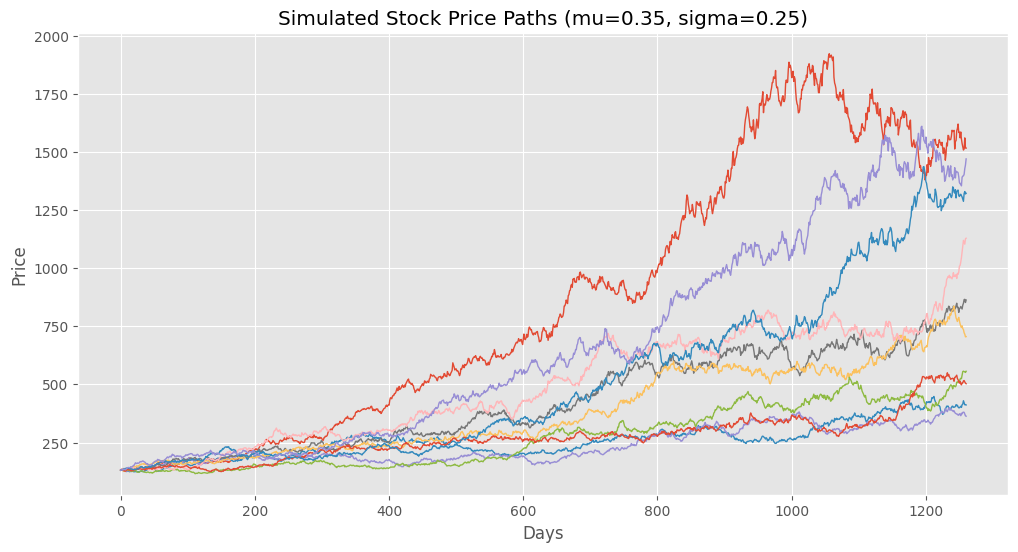

996 of 1,000 paths finished above the initial price.


In [3]:
price_paths = gbm_levels(s0, dt, sigma, time, mu, paths)

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(price_paths[:, i], linewidth=1)
plt.title("Simulated Stock Price Paths (mu=0.35, sigma=0.25)")
plt.xlabel("Days")
plt.ylabel("Price")
plt.grid(True)
plt.show()

print(f"{np.sum(price_paths[-1, :] > s0)} of 1,000 paths finished above the initial price.")

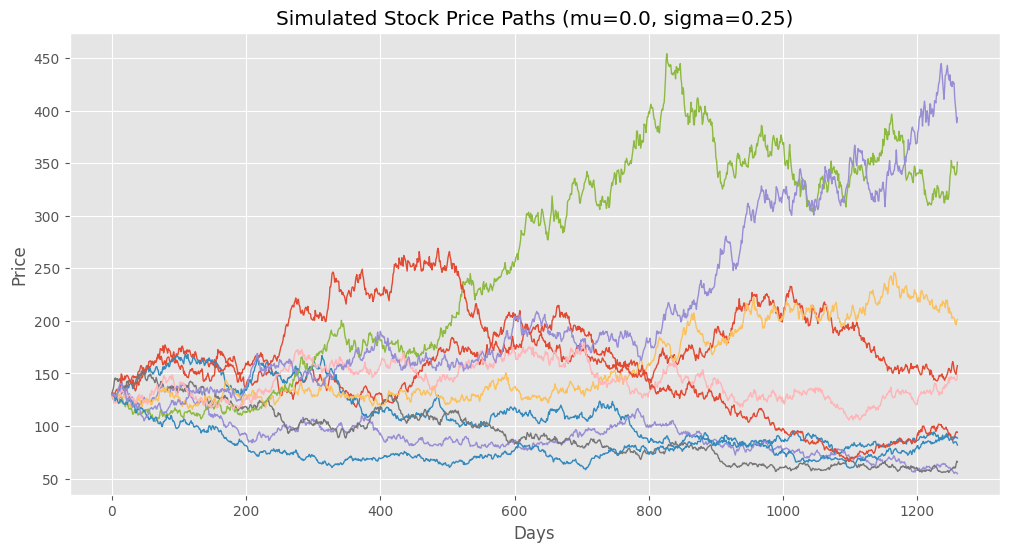

409 of 1,000 paths finished above the initial price.


In [4]:
price_paths = gbm_levels(s0, dt, sigma, time, 0.0, paths)

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(price_paths[:, i], linewidth=1)
plt.title("Simulated Stock Price Paths (mu=0.0, sigma=0.25)")
plt.xlabel("Days")
plt.ylabel("Price")
plt.grid(True)
plt.show()

print(f"{np.sum(price_paths[-1, :] > s0)} of 1,000 paths finished above the initial price.")